<a href="https://colab.research.google.com/github/D2718281828nis/AutomaticControlTheory-Denoising_Signals/blob/main/AE_EEG_Unsupervised_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# Autoencoder Model for Unsupervised Anomaly Detection (Healthy vs Seizure)

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense, Reshape, BatchNormalization, LeakyReLU, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle

Here's a concise markdown explanation of how this code works:

---

# Epilepsy Detection: CNN-LSTM Pipeline

## Overview
This notebook implements an **end-to-end pipeline** for epileptic seizure detection using EEG signals. It converts raw EDF brain recordings into wavelet spectrogram images, then classifies them using a **CNN-LSTM deep learning model**.

---

## 1. Data Acquisition & Preprocessing

### Download EEG Data
- Downloads `.edf` files from **PhysioNet CHB-MIT** database (epilepsy patients)
- Parses summary files to extract seizure start/end times

### Signal Processing Pipeline
| Step | Function | Description |
|------|----------|-------------|
| **Read** | `read_edf()` | Loads multi-channel EEG signals from EDF files |
| **Filter** | `butter_bandpass_filter()` | Extracts 5 frequency bands: Delta (1-4Hz), Theta (4-8Hz), Alpha (8-14Hz), Beta (14-30Hz), Gamma (30-50Hz) |
| **Clean** | `mean_delete()` | Removes DC offset using sliding window averaging |
| **Transform** | `save_wavelet_transform()` | Generates **wavelet spectrograms** (Morlet wavelet) for each frequency band |

### Image Generation Strategy
- **Seizure samples**: 30-second windows at 30/60/90 seconds *before* seizure onset
- **Healthy samples**: 30-second window from middle of seizure-free recordings
- Output: 5-band wavelet heatmaps saved as PNG images (512×512×4)

---

## 2. Model Architecture (CNN + LSTM)

```
Input (512×512×4)
    → Conv2D(32) → BatchNorm → MaxPool → Dropout(0.5)
    → Conv2D(64) → MaxPool → Dropout(0.5)  
    → Conv2D(128) → MaxPool → Dropout(0.5)
    → Flatten → Dense(64) + L2 regularization
    → Reshape → LSTM(64)  [captures temporal dependencies]
    → Dense(32) → Output(2 classes, sigmoid)
```

**Key Features:**
- **CNN layers**: Extract spatial features from wavelet spectrograms
- **LSTM layer**: Captures temporal patterns across frequency bands
- **Class weights**: Handles imbalance between seizure/healthy samples

---

## 3. Training & Evaluation

| Component | Setting |
|-----------|---------|
| Loss | `categorical_crossentropy` |
| Optimizer | Adam (lr=1e-3) |
| Callbacks | Early stopping (patience=40), Model checkpoint |
| Metrics | Accuracy, Confusion Matrix, ROC-AUC, Precision-Recall |

---

## 4. Inference on New Data

1. Downloads unseen EDF from **Zenodo** repository
2. Applies same preprocessing pipeline (filter → wavelet transform)
3. Loads saved model (`cnn_eeg_epilepsy_model.h5`)
4. Predicts seizure probability

---

## Summary Flow

```
Raw EDF → Bandpass Filter → Wavelet Transform → Spectrogram Image
                                              ↓
                    Seizure/Healthy ← CNN-LSTM Classifier ← Image (512×512×4)
```

**Result**: Automated epilepsy detection from raw EEG signals using time-frequency representations and deep learning.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from os import listdir

#обратите внимание - надо указать путь до своей папки на гугл-диске
os.chdir('/content/drive/MyDrive/edf_process/CNN_NN_learning')

# --- 1. Data Loading Functions ---

In [14]:

def load_images_by_class(image_dir, target_size, class_label_to_load):
    """Loads images belonging to a specific class."""
    images = []
    class_path = os.path.join(image_dir, class_label_to_load)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = tf.keras.utils.load_img(img_path, color_mode='rgb', target_size=target_size) # Ensure RGB
            img_array = tf.keras.utils.img_to_array(img)
            images.append(img_array)
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

    images = np.array(images)
    print(f"Loaded {images.shape[0]} images from '{class_label_to_load}' class.")
    return images

def display_samples(X, num_samples=5, title="Sample Images"):
    """Displays a grid of sample images."""
    if len(X) < num_samples:
        num_samples = len(X)

    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 3, 3))
    if num_samples == 1:
        axes = [axes]
    for i in range(num_samples):
        # Display float images directly, assuming they are in [0.0, 1.0] range
        axes[i].imshow(X[i])
        axes[i].axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# --- 2. Autoencoder Model Definition ---

In [15]:

def create_autoencoder(input_shape):
    """Creates a convolutional autoencoder model."""

    # Encoder
    encoder_input = Input(shape=input_shape, name="encoder_input")

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Dropout(0.2)(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Dropout(0.2)(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x) # Bottleneck layer

    # Decoder
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x) # Output shape must match input, 3 channels for RGB

    # Full Autoencoder Model
    autoencoder = Model(encoder_input, decoded, name="autoencoder")

    # Separate Encoder Model (optional, for analysis)
    encoder = Model(encoder_input, encoded, name="encoder")

    # Separate Decoder Model (optional, for analysis)
    # The decoder's input should be the shape of the 'encoded' tensor
    decoder_input = Input(shape=encoded.shape[1:], name="decoder_input")

    _x_decoder = decoder_input
    # Iterate through the layers of the autoencoder that constitute the decoder part
    # The decoder layers start from the layer that takes 'encoded' as input in the autoencoder.
    # In the autoencoder model, the 'encoded' output is produced by autoencoder.layers[10] (MaxPooling2D).
    # The first layer of the decoder part is autoencoder.layers[11] (Conv2D(128)).
    for i in range(11, len(autoencoder.layers)):
        _x_decoder = autoencoder.layers[i](_x_decoder)

    _decoded_output = _x_decoder
    decoder = Model(decoder_input, _decoded_output, name="decoder")

    return autoencoder, encoder, decoder


# Define paths and parameters

In [16]:
# Define paths and parameters
image_dir = '/content/drive/MyDrive/edf_process/CNN_NN_learning/wavelet_img/'
target_size = (512, 512)
input_shape = (*target_size, 3) # Assuming RGB images
batch_size = 8
epochs = 20 # Potentially need more epochs for unsupervised learning

# Change directory (optional, might not be needed depending on environment)
# os.chdir(image_dir)

print("Loading 'Healthy' images for training...")
X_healthy = load_images_by_class(image_dir, target_size, 'Healthy')
X_seizure = load_images_by_class(image_dir, target_size, 'Seizure')

if X_healthy.size == 0 or X_seizure.size == 0:
    raise ValueError("One or both classes ('Healthy', 'Seizure') could not be loaded or are empty.")

Loading 'Healthy' images for training...
Loaded 153 images from 'Healthy' class.
Loaded 84 images from 'Seizure' class.


# Display samples

Training set size (Healthy): 137
Validation set size (Healthy): 16
Test set size (Seizure): 84


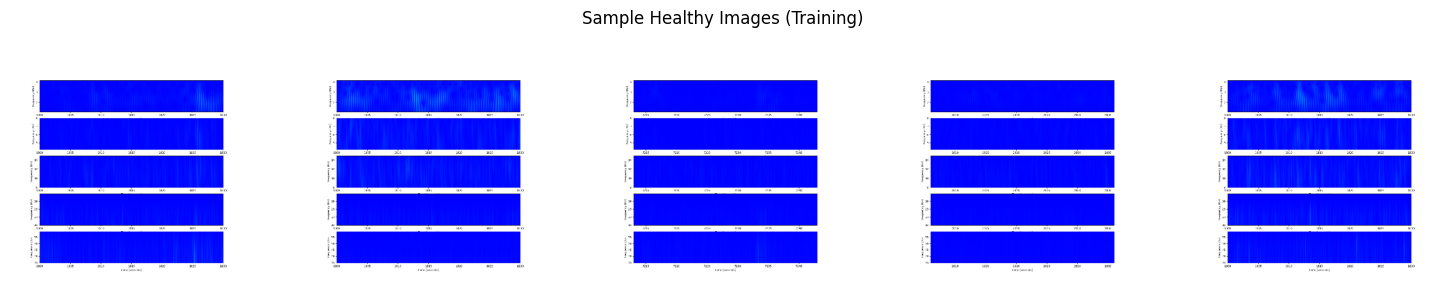

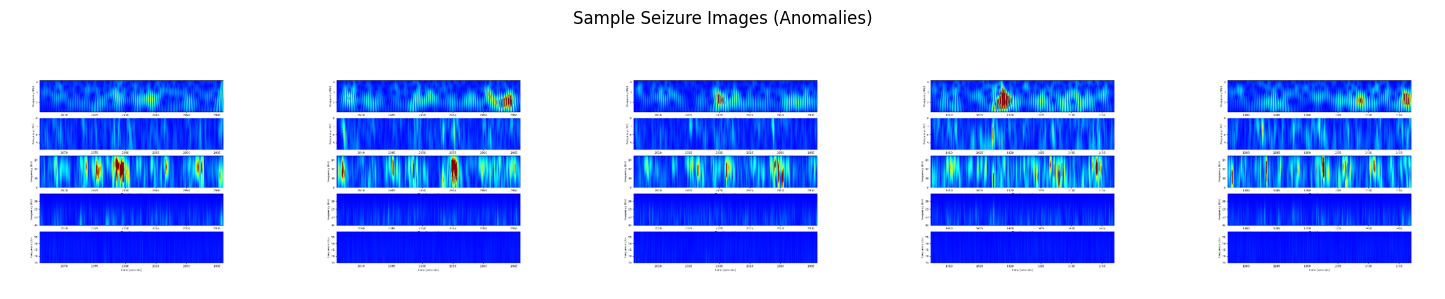

In [17]:

# Normalize pixel values to [0, 1]
X_healthy = X_healthy.astype('float32') / 255.0
X_seizure = X_seizure.astype('float32') / 255.0

# Shuffle the healthy data
X_healthy, _ = shuffle(X_healthy, np.arange(len(X_healthy)), random_state=24)

# Split healthy data into train and a small validation set for the autoencoder
X_healthy_train, X_healthy_val = train_test_split(X_healthy, test_size=0.1, random_state=42)

print(f"Training set size (Healthy): {X_healthy_train.shape[0]}")
print(f"Validation set size (Healthy): {X_healthy_val.shape[0]}")
print(f"Test set size (Seizure): {X_seizure.shape[0]}")

# Display samples
display_samples(X_healthy_train[:5], num_samples=5, title="Sample Healthy Images (Training)")
display_samples(X_seizure[:5], num_samples=5, title="Sample Seizure Images (Anomalies)")

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 512, 512, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 512, 512, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 256, 256, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 512, 512, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 512, 512, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,235 (1.28 MB)

 Trainable params: 334,595 (1.28 MB)

 Non-trainable params: 640 (2.50 KB)


--- Training Autoencoder on 'Healthy' images ---
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - loss: 0.1381 - mae: 0.2777 
Epoch 1: val_loss improved from None to 0.27424, saving model to best_autoencoder_weights.keras

Epoch 1: finished saving model to best_autoencoder_weights.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 303s 16s/step - loss: 0.1016 - mae: 0.2170 - val_loss: 0.2742 - val_mae: 0.4425
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - loss: 0.0554 - mae: 0.1407 
Epoch 2: val_loss improved from 0.27424 to 0.15574, saving model to best_autoencoder_weights.keras

Epoch 2: finished saving model to best_autoencoder_weights.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 330s 17s/step - loss: 0.0479 - mae: 0.1304 - val_loss: 0.1557 - val_mae: 0.3303
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - loss: 0.0283 - mae: 0.0941 
Epoch 3: val_loss improved from 0.15574 to 0.14106, saving model to best_autoencoder_weights.keras

Epoch 3: finished saving model to best_autoencoder_weights.keras
18/1

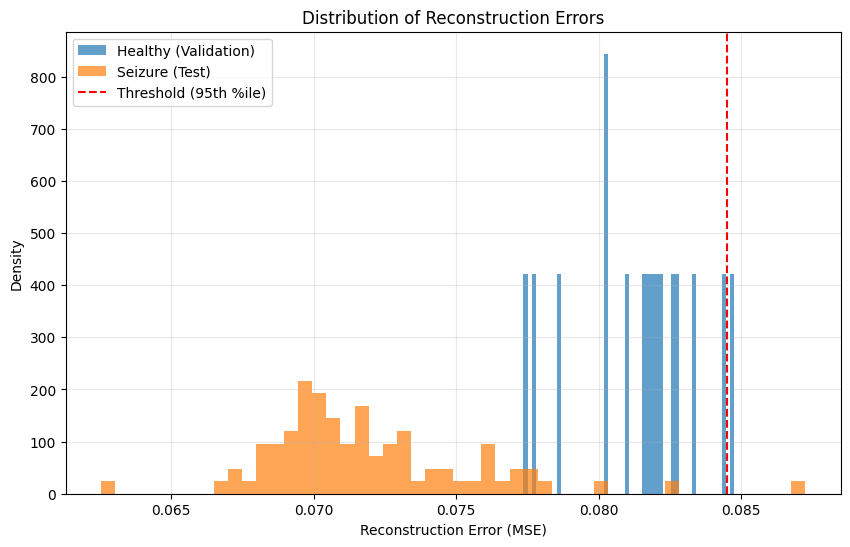

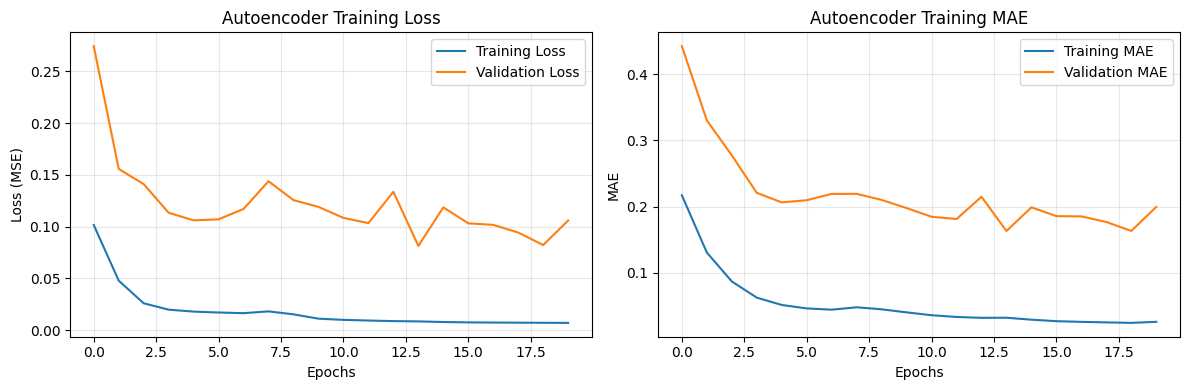

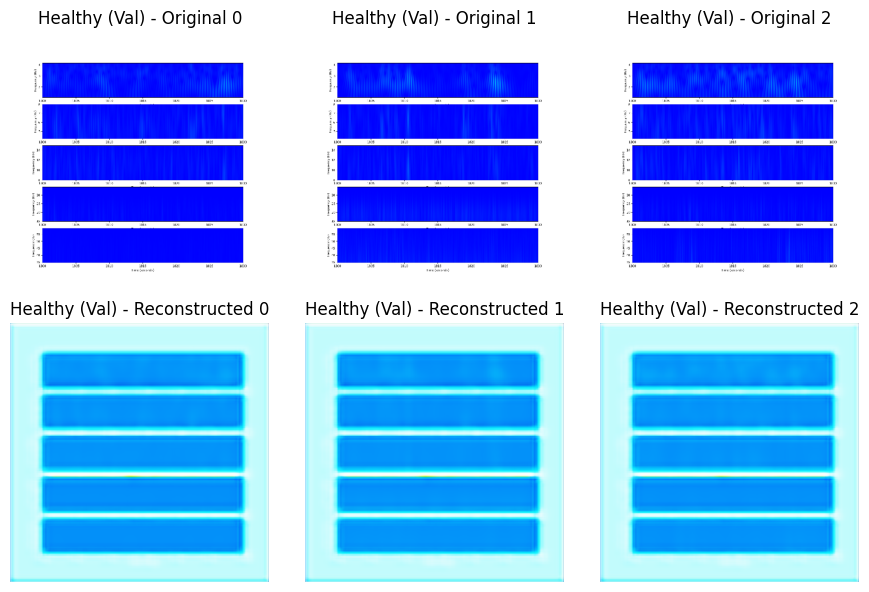

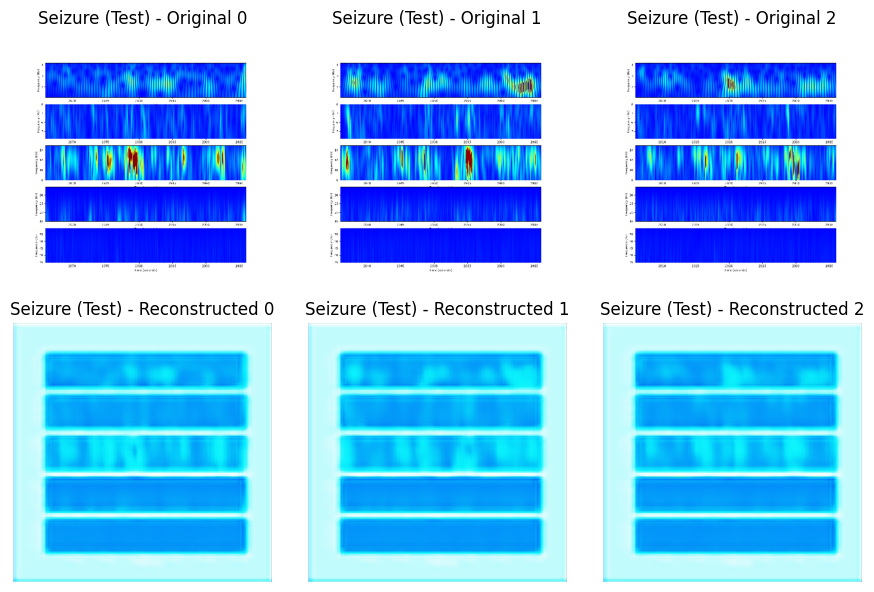

In [18]:
# Create the autoencoder model
autoencoder_model, encoder_model, decoder_model = create_autoencoder(input_shape)
autoencoder_model.summary()

# Compile the autoencoder
autoencoder_model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae']) # MSE is common for reconstruction

# Define callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_autoencoder_weights.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# Train the autoencoder on Healthy images only
print("\n--- Training Autoencoder on 'Healthy' images ---")
history = autoencoder_model.fit(
    X_healthy_train, X_healthy_train, # Input and target are the same for autoencoders
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_healthy_val, X_healthy_val),
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

# --- 4. Evaluate Anomaly Detection Performance ---

# Reconstruct the validation set (should be low error)
reconstructions_val = autoencoder_model.predict(X_healthy_val, verbose=0)
reconstruction_errors_val = np.mean(np.square(X_healthy_val - reconstructions_val), axis=(1, 2, 3)) # MSE per image

# Reconstruct the seizure set (should be high error)
reconstructions_seizure = autoencoder_model.predict(X_seizure, verbose=0)
reconstruction_errors_seizure = np.mean(np.square(X_seizure - reconstructions_seizure), axis=(1, 2, 3))

# Combine errors and create labels for evaluation
all_errors = np.concatenate([reconstruction_errors_val, reconstruction_errors_seizure])
all_labels = np.concatenate([np.zeros(len(reconstruction_errors_val)), np.ones(len(reconstruction_errors_seizure))]) # 0=Normal, 1=Anomaly

# Determine a threshold for anomaly detection (e.g., using percentile or mean+std of val errors)
threshold_percentile = 95 # Example: Use 95th percentile of healthy val errors
threshold = np.percentile(reconstruction_errors_val, threshold_percentile)
print(f"\nUsing threshold at {threshold_percentile}th percentile of Healthy validation errors: {threshold:.6f}")

# Classify based on threshold
predicted_anomaly = (all_errors > threshold).astype(int)

# Calculate metrics
accuracy = accuracy_score(all_labels, predicted_anomaly)
roc_auc = roc_auc_score(all_labels, all_errors) # Using raw errors for AUC calculation
print("\n--- Evaluation Results ---")
print(f"Threshold ({threshold_percentile}th percentile): {threshold:.6f}")
print(f"Accuracy (based on threshold): {accuracy:.4f}")
print(f"ROC AUC Score (using reconstruction errors): {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, predicted_anomaly, target_names=["Normal (Healthy)", "Anomaly (Seizure)"]))

# --- 5. Visualizations ---

# Plot Reconstruction Errors
plt.figure(figsize=(10, 6))
plt.hist(reconstruction_errors_val, bins=50, alpha=0.7, label='Healthy (Validation)', density=True)
plt.hist(reconstruction_errors_seizure, bins=50, alpha=0.7, label='Seizure (Test)', density=True)
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold_percentile}th %ile)')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.title('Distribution of Reconstruction Errors')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Autoencoder Training MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Display some original vs reconstructed examples from both sets
def show_reconstructions(originals, reconstructions, title_prefix, num_samples=3):
    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 3, 6))
    for i in range(min(num_samples, originals.shape[0])):
        # Original
        axes[0, i].imshow(originals[i])
        axes[0, i].set_title(f'{title_prefix} - Original {i}')
        axes[0, i].axis('off')
        # Reconstructed
        axes[1, i].imshow(reconstructions[i])
        axes[1, i].set_title(f'{title_prefix} - Reconstructed {i}')
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()

# Show examples from Healthy validation set
recon_val_examples = autoencoder_model.predict(X_healthy_val[:3], verbose=0)
show_reconstructions(X_healthy_val[:3], recon_val_examples, "Healthy (Val)")

# Show examples from Seizure test set
recon_seizure_examples = autoencoder_model.predict(X_seizure[:3], verbose=0)
show_reconstructions(X_seizure[:3], recon_seizure_examples, "Seizure (Test)")